In [17]:
# import pandas as pd
# import numpy as np
# import os
# import  glob

# !pip install duckdb

# note tables so far
# stocks
# stocks_clean
# stocks_features
# stocks_features_clean
# stocks_futures_labeled

# **PHASE 1 — DATA FOUNDATION**
- Let get all trade summary file from local folder
- merge them into single master csv data file
- normalize column names for better understanding and model standards

Company Name| Symbol| Share Volume| Trade Volume| Previous Close (Rs.)| Open (Rs.)| High (Rs.)|Low (Rs.)| **Last Trade (Rs.)| Change (Rs.)| Change (%)

##### Before modeling, you should now write a schema mapper that converts this raw exchange format → standardized ML format
Last Trade	    >  close<br>
Previous Close	>  prev_close<br>
Share Volume	>  volume<br>
Trade Volume	>  trades<br>

### Scan "C:\Users\Lapmart\Downloads\CSE" folder and crate master data set

## **Data handling with pandas**
- slower when having millions of data

In [ ]:
import pandas as pd
import os
import glob
from datetime import datetime

# To see all columns, if not then we see '...' in middle
pd.set_option('display.max_columns', None)

# ================ CONFIG ===================

FOLDER = r"C:\Users\Lapmart\Downloads\CSE"
OUTPUT = "MASTER_CSE_DATA.csv"

os.makedirs("log", exist_ok=True)
LOG_FILE = LOG_FILE = os.path.join("log", f"loader_log_{datetime.now().strftime('%Y%m%d_%H%M%S')}.txt")


# ================ HELPERS =============

def log(msg):
    with open(LOG_FILE, "a", encoding="utf-8") as f:
        f.write(msg + "\n")
    print(msg)

def extract_date(filename):
    try:
        raw = filename.split("_")[0]
        return datetime.strptime(raw, "%y%m%d")
    except:
        log(f"### Error exctracting name from {filename}")
        return None

# Column mapping
COLUMN_MAP = {
    "Company Name": "company",
    "Symbol":"symbol",
    "Low (Rs.)": "low",
    "**Last Trade (Rs.)": "close",
    "Previous Close (Rs.)": "prev_close",
    "Open (Rs.)": "open",
    "High (Rs.)": "high",
    "Share Volume": "volume",
    "Trade Volume": "trades",
    "Change(Rs)": "change",
    "Change (Rs.)": "change",
    "Change (%)": "change_percentage"
}


# ================ LOAD FILES ========================

files = glob.glob(os.path.join(FOLDER, "*.csv"))

log("=== LOADER START USING PANDAS FOR DATA ===")
log(f"Total files found: {len(files)}")

valid_frames = []
valid_dates = []

for file in files:
    name = os.path.basename(file)

     # ---- check filename date
    date = extract_date(name)
    if date is None:
        log(f"INVALID DATE FORMAT → skipped: {name}")
        continue

    # ---- read csv
    try:
        df = pd.read_csv(file)
    except Exception as e:
        log(f"### READ ERROR → {name} → {e}")
        continue
        
    # ---- empty file check
    if df.empty:
        log(f"EMPTY FILE → skipped: {name}")
        continue

    # ---- normalize column names
    df.columns = [col.strip() for col in df.columns]  # remove extra spaces
    df.rename(columns=COLUMN_MAP, inplace=True)
    
    # ---- add date column
    df["date"] = date

    valid_frames.append(df)
    valid_dates.append(date)


# ================ MERGE =======================

if not valid_frames:
    log("NO VALID FILES FOUND")
    exit()
    
# combine all files
master = pd.concat(valid_frames, ignore_index=True)


# ================ DUPLICATE CHECK =====================

dupes = master.duplicated(subset=["symbol","date"])
dup_count = dupes.sum()

if dup_count > 0:
    log(f"DUPLICATES FOUND: {dup_count} rows removed")
    master = master[~dupes]


# ================ SORT ========================

master = master.sort_values(["symbol", "date"])


# # ================ MISSING DATE REPORT ==================

# valid_dates = sorted(set(valid_dates))
# missing_days = []

# for i in range(len(valid_dates)-1):
#     diff = (valid_dates[i+1] - valid_dates[i]).days
#     if diff > 1:
#         missing_days.append((valid_dates[i], valid_dates[i+1]))

# if missing_days:
#     log("MISSING DATE GAPS:")
#     for g in missing_days:
#         log(f"{g[0].date()} → {g[1].date()}")


# ================ SAVE =======================
        
master.to_csv(OUTPUT, index=False)

log(f"MASTER DATASET CREATED → {OUTPUT}")
log("=== LOADER FINISHED ===")
print("DONE — Master dataset created using pandas")


## **Data Hndling with DuckDB**

### Why Data Engineers Prefer DuckDB
- Real data pipelines often use it for:
- stock market analysis
- log processing
- machine learning datasets
- financial backtesting
- Because it handles millions to billions of rows locally
#### What we do here
- Creating the connection to DuckDB
- Creating a database named "cse_data.db"
- Craeting relvent tablesd to store data
- Read csv cin folder & add them into table
- Ensure data quality & Data cleaning
- Standardization the columns names
- Sorting
- Indexing(symbol &  date) for speed data accessing
- exporting final table as **MASTER_CSE_DATA.csv**

In [50]:
import pandas as pd # only for csv reading, column name standaization
import os
import glob # finds files/folders matching patterns like wildcards in Python
from datetime import datetime
import duckdb

pd.set_option('display.max_columns', None)



# ================ CONFIG ===================

FOLDER = r"C:\Users\Lapmart\Downloads\CSE" # my local stored folder path
OUTPUT = "MASTER_CSE_DATA.csv" # Name of the master data file

os.makedirs("log", exist_ok=True) # Create log folder if doesn't exit
# dynamically names a log file using the current date & time
LOG_FILE = os.path.join("log", f"loader_log_{datetime.now().strftime('%Y%m%d_%H%M%S')}.txt")



# ================ HELPERS =================

# method to add log msg into log file & prints them to console
def log(msg):
    with open(LOG_FILE, "a", encoding="utf-8") as f: # "a" mode → appends messages instead of overwriting
        f.write(msg + "\n")
    print(msg)

# Method to extract date from file name in format like 260210_tradesummary.csv.
def extract_date(filename):
    try:
        raw = filename.split("_")[0]
        return datetime.strptime(raw, "%y%m%d")
    except:
        return None

# Standardize column names, helper map for mapping existing unusual column names into standard names 
COLUMN_MAP = {
    "Company Name": "company",
    "Symbol":"symbol",
    "Share Volume": "volume",
    "Low (Rs.)": "low",
    "**Last Trade (Rs.)": "close",
    "Previous Close (Rs.)": "prev_close",
    "Open (Rs.)": "open",
    "High (Rs.)": "high",
    "Trade Volume": "trades",
    "Change(Rs)": "change",
    "Change (Rs.)": "change",
    "Change (%)": "change_percentage"
}



# ================= CONNECT DUCKDB =================

# remove exiting database
try :
    con.close()
    import os
    os.remove("cse_data.db")
    print("closed connection of duckdb & deleted cse_data.db file...")
except Exception as e:
    print("There is no database connectionto close: ", e)

con = duckdb.connect(database="cse_data.db")  # Create/connect DB
log("Creating DuckDB table 'stocks_table' ...")

con.execute("""
CREATE TABLE IF NOT EXISTS stocks_table (
    company TEXT,
    symbol TEXT,
    volume INTEGER,
    trades INTEGER,
    prev_close DOUBLE,
    open DOUBLE,
    high DOUBLE,
    low DOUBLE,
    close DOUBLE,
    change DOUBLE,
    change_percentage DOUBLE,
    date DATE
)
""")



# ================= LOAD CSVs DIRECTLY =================

log("=== LOADER START WITH DUCKDB FOR DATA HANDLING ===")

files = glob.glob(os.path.join(FOLDER, "*.csv"))
total_csv_files = len(files)
log(f"Total files found: {total_csv_files}")

for file in files:
    filename = os.path.basename(file) # extract base name
    date = extract_date(filename) # get date from filename though function extract_date()
    
    if date is None:
        log(f"### INVALID DATE FORMAT → skipped: {filename}")
        total_csv_files -= 1
        continue # Go back to the top of the loop, Start next file

    # ---- read csv
    try:
        df = pd.read_csv(file)
        if df.empty:
            log(f"EMPTY FILE → skipped: {filename}")
            continue
    except Exception as e:
        log(f"READ ERROR → {filename} → {e}")
        total_csv_files -= 1
        continue
        
    # ---- Standardize column names, We assign a new list to df.columns to update the column names after processing them
    df.columns = [col.strip() for col in df.columns]  # remove extra spaces
    df.rename(columns=COLUMN_MAP, inplace=True) # Renames columns based on COLUMN_MAP.


    # ======== DATA QUALITY REPORT =========
    
    no_of_total_rows = len(df)
    no_of_missing_symbol = df["symbol"].isna().sum() if "symbol" in df.columns else total_rows
    no_of_missing_close = df["close"].isna().sum() if "close" in df.columns else total_rows

    # This cols contain only numeric values later ensure it
    numeric_cols = ["low","close","prev_close","open","high","volume","trades","change","change_percentage"]
    invalid_numeric = {}

    # Make sure selected columns are really numeric numbers, not strings
    # It does NOT modify the DataFrame yet, It only checks and reports problems
    for col in numeric_cols:
        if col in df.columns:    # Check if that column actually exists in the DataFrame
            #  pd.to_numeric --> tries to convert the column into numbers
            # errors="coerce" ---> If a value cannot be converted, replace it with: NaN, Instead of crashing program
            # conv col into numeric col if invalid, mark as Nan that data ell count Nans & that record add into "invalid_numeric" dictionary
            invalid_numeric[col] = pd.to_numeric(df[col], errors="coerce").isna().sum()
    
    is_show_dq_report = False
    
    if(no_of_missing_symbol > 0 or no_of_missing_close > 0):
        is_show_dq_report = True
        log("\n============== ERRORS ! DATA QUALITY REPORT ==============")
        log(f"FILE: {filename}")
        log(f"Total rows: {no_of_total_rows}")
        log(f"Missing symbols: {no_of_missing_symbol}")
        log(f"Missing close prices: {no_of_missing_close}")

    for col, count in invalid_numeric.items():
        if count > 0:
            is_show_dq_report = True
            log(f"Invalid numeric values in {col}: {count}")

    # check negative prices
    if "close" in df.columns:
        neg_price = (pd.to_numeric(df["close"], errors="coerce") <= 0).sum()
        if neg_price > 0:
            is_show_dq_report=True
            log(f"Invalid negative prices: {neg_price}")

    if is_show_dq_report:
        log("============== ENF OF DATA QUALITY REPORT ==============\n")

    
    # ================= CLEAN DATA =================

    no_of_rows_before_clean = len(df)

    # remove rows where symbol missing BEFORE casting to string
    if "symbol" in df.columns:
        df = df[df["symbol"].notna()]
        
    # strip spaces
    if "symbol" in df.columns:
        df = df[df["symbol"].notna()]
        df["symbol"] = df["symbol"].astype(str).str.strip()

    if "company" in df.columns:
        df["company"] = df["company"].astype(str).str.strip()
    
    # convert numeric columns
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # remove rows where close price missing
    if "close" in df.columns:
        df = df[df["close"].notna()]

    # remove impossible values
    if "close" in df.columns:
        df = df[df["close"] > 0]

    if "volume" in df.columns:
        df = df[df["volume"] >= 0]

    # fix percentage anomalies
    if "change_percentage" in df.columns:
        df.loc[(df["change_percentage"] < -100) | (df["change_percentage"] > 1000), "change_percentage"] = None

    # drop fully empty rows
    df = df.dropna(how="all")

    no_of_rows_after_clean = len(df)
    
    if(no_of_rows_before_clean > no_of_rows_after_clean):
        log("\n========== DATA CLEAN REPORT ========")
        log(f"Some rows removed, File : {filename} before cleaning → {no_of_rows_before_clean} rows, After {no_of_rows_after_clean} rows\n")

    if len(df) == 0:
        log(f"ALL ROWS REMOVED AFTER CLEANING → skipped {filename}")
        continue
    
    # ---- add date column
    df["date"] = date

     # ------- Insert directly into DuckDB 'stocks_table' table
    con.register("temp_df", df)
    
    # Before inserting, enforce column order:
    df = df[
        [
        "company",
        "symbol",
        "volume",
        "trades",
        "prev_close",
        "open",
        "high",
        "low",
        "close",
        "change",
        "change_percentage",
        "date"
        ]]

    con.execute("""
        INSERT INTO stocks_table (
            company,
            symbol,
            volume,
            trades,
            prev_close,
            open,
            high,
            low,
            close,
            change,
            change_percentage,
            date
        )
        SELECT
            company,
            symbol,
            volume,
            trades,
            prev_close,
            open,
            high,
            low,
            close,
            change,
            change_percentage,
            date
        FROM temp_df
        """)
        
   
    con.execute("INSERT INTO stocks_table SELECT * FROM temp_df")
    # log(f"Inserted {len(df)} rows from {filename}")

log(f"{total_csv_files} CSVs inserted into DuckDB.")



# ================  REMOVE DUPLICATES =====================
# Removes duplicate rows for the same symbol and date
# numbers duplicate rows starting from 1
# WHERE rn = 1 → keeps only the first row of each symbol/date combination

log("Removing duplicates...")

# Creates a table named stocks_clean_table
# If it already exists → deletes old one and recreates it
# add ne column dup_index, assign occurnce counnt for each record only keeep occurence number 1 others will be delted
# 
con.execute("""
CREATE OR REPLACE TABLE stocks_clean_table AS
SELECT *
FROM (
    SELECT *,
           ROW_NUMBER() OVER (
               PARTITION BY symbol, date
               ORDER BY date
           ) AS dup_index
    FROM stocks_table
)
WHERE dup_index = 1
""")



# ================ SORT ========================

log("Sorting dataset...")

# Create new table that cotain sorted data by symbol then date
con.execute("""
CREATE OR REPLACE TABLE stocks_sorted_table AS
SELECT *
FROM stocks_clean_table
ORDER BY symbol, date
""")



# ================ CREATE INDEX ========================

log("Creating composite index on symbol+date for speed...")

# Adds a composite index on (symbol, date)
# Speeds up all queries that filter by symbol, date, or both
con.execute("""
CREATE INDEX IF NOT EXISTS idx_symbol_date ON stocks_sorted_table(symbol, date)
""")



# ================ MISSING DATE REPORT ==================
# TODO : if needed



# ================ EXPORT =======================

log("Exporting final CSV...")

con.execute(f"""
COPY stocks_sorted_table TO '{OUTPUT}' (HEADER, DELIMITER ',')
""")

log(f"MASTER DATASET CREATED → {OUTPUT}")
log("=== LOADER FINISHED USING DUCKDB ===")
print("DONE — Master dataset created")

stocks_table_df = con.execute("""
SELECT *
FROM stocks_table
""").fetchdf()

print("\n==========Summury fo stocks_table=========")
stocks_table_df.head()

# stocks_table
# stocks_clean_table
# stocks_sorted_table

closed connection of duckdb & deleted cse_data.db file...
Creating DuckDB table 'stocks_table' ...
=== LOADER START WITH DUCKDB FOR DATA HANDLING ===
Total files found: 60

============== ERRORS ! DATA QUALITY REPORT ==============
FILE: 260228_trade-summary-test-dup.csv
Total rows: 293
Missing symbols: 1
Missing close prices: 1
Invalid numeric values in close: 1
============== ENF OF DATA QUALITY REPORT ==============


========== DATA CLEAN REPORT ========
Some rows removed, File : 260228_trade-summary-test-dup.csv before cleaning → 293 rows, After 291 rows


============== ERRORS ! DATA QUALITY REPORT ==============
FILE: 260228_trade-summary-test.csv
Total rows: 293
Missing symbols: 1
Missing close prices: 1
Invalid numeric values in close: 1
============== ENF OF DATA QUALITY REPORT ==============


========== DATA CLEAN REPORT ========
Some rows removed, File : 260228_trade-summary-test.csv before cleaning → 293 rows, After 291 rows

60 CSVs inserted into DuckDB.
Removing duplica

,company,symbol,volume,trades,prev_close,open,high,low,close,change,change_percentage,date
0,INDUSTRIAL ASPHALTS (CEYLON) PLC,ASPH.N0000,14032048,177,0.40,0.50,0.5,0.40,0.50,0.10,25.00,2025-10-23
1,RADIANT GEMS INTERNATIONAL PLC,RGEM.N0000,76307,280,83.60,88.00,104.5,86.00,104.00,20.40,24.40,2025-10-23
2,LAKE HOUSE PRINTERS & PUBLISHERS PLC,LPRT.N0000,2384,152,475.75,480.00,594.5,480.00,591.00,115.25,24.22,2025-10-23
3,BAIRAHA FARMS PLC,BFL.N0000,249279,1254,384.75,409.75,470.0,409.75,458.25,73.50,19.10,2025-10-23
4,KERNER HAUS GLOBAL SOLUTIONS PLC,CPRT.N0000,1322,112,540.75,552.00,675.0,552.00,639.25,98.50,18.22,2025-10-23


### Test speed of query execution with indexing

In [51]:
# commnet above code's indexing part and give a dofferent name for db cvvration try it with below code
# try agian with uncommenting

import time
import duckdb

# Change this to the DB you want to test
con = duckdb.connect("cse_data.db")  # or 'cse_data_index.db'

start = time.time()
results = con.execute("""
SELECT * FROM stocks_sorted_table WHERE symbol='TAJ.N0000'
""").fetchall()
end = time.time()

print(f"Rows returned: {len(results)}")
print(f"Query time: {end - start:.4f} seconds")

Rows returned: 58
Query time: 0.0022 seconds


In [52]:
df.columns

Index(['company', 'symbol', 'volume', 'trades', 'prev_close', 'open', 'high',
       'low', 'close', 'change', 'change_percentage', 'date'],
      dtype='object')

### Master Data CSV Summary

In [53]:
MASTER_CSE_DATA_df = pd.read_csv(r"C:\Users\Lapmart\Jupyter AI Projects\CSE Investment Assistence with XGBoost\MASTER_CSE_DATA.csv")
MASTER_CSE_DATA_df.head()

,company,symbol,volume,trades,prev_close,open,high,low,close,change,change_percentage,date,dup_index
0,ASIA ASSET FINANCE PLC,AAF.N0000,184992,102,61.7,61.5,63.0,60.8,60.9,-0.8,-1.30,2025-10-23,1
1,ASIA ASSET FINANCE PLC,AAF.N0000,225496,128,60.9,61.6,62.0,60.0,60.3,-0.6,-0.99,2025-10-24,1
2,ASIA ASSET FINANCE PLC,AAF.N0000,217100,171,60.3,61.0,61.0,58.5,59.2,-1.1,-1.82,2025-10-27,1
3,ASIA ASSET FINANCE PLC,AAF.N0000,107995,93,59.2,60.9,61.0,59.0,59.9,0.7,1.18,2025-10-28,1
4,ASIA ASSET FINANCE PLC,AAF.N0000,217448,101,59.9,60.0,62.0,59.0,60.5,0.6,1.00,2025-10-29,1


In [54]:
MASTER_CSE_DATA_df.tail()

,company,symbol,volume,trades,prev_close,open,high,low,close,change,change_percentage,date,dup_index
16868,YORK ARCADE HOLDINGS PLC,YORK.N0000,283675,231,14.3,14.2,15.7,14.2,15.2,0.9,6.29,2026-03-05,1
16869,YORK ARCADE HOLDINGS PLC,YORK.N0000,219777,162,16.5,17.0,17.4,16.1,16.3,-0.2,-1.21,2026-03-06,1
16870,YORK ARCADE HOLDINGS PLC,YORK.N0000,373454,244,16.3,16.6,16.6,15.3,15.5,-0.8,-4.91,2026-03-09,1
16871,YORK ARCADE HOLDINGS PLC,YORK.N0000,494718,263,15.5,16.0,17.2,15.9,16.6,1.1,7.10,2026-03-10,1
16872,YORK ARCADE HOLDINGS PLC,YORK.N0000,57503,64,16.6,16.7,16.8,16.0,16.1,-0.5,-3.01,2026-03-11,1


# **PHASE 2 — FEATURE ENGINEERING ENGINE**
- For 10 day profit
- let create new table **stocks_features_table** > reads data from table **stocks_sorted_table** > copies all original columns > Adds new calculated columns
- WINDOW w → defines a reusable window that we can use any where insted of typing long query several times,it say defines how rows are grouped and ordered
  - grouped by stock symbol
  - ordered by date
- **We will create columns / features for model training here**
  - wef

### Create Feature Table Base

In [55]:
import numpy as np

In [56]:
# ============== Create Feature Table Base ===========================================================

log("Creating feature base table...")

# Opens a connection to a DuckDB database file named cse_data.db, If it doesn’t exist, DuckDB creates it
con = duckdb.connect(database="cse_data.db")

# Reset tables, cols
con.execute("""
    DROP TABLE IF EXISTS stocks_table;
""")


# Creates a table called stocks_features_table, If it already exists → replaces it
# SELECT *,  > Selects all columns from stocks_sorted_table last validt table
# LAG window function looks backward in the result set, returns the value of the close column from 5 rows earlier

# close_5d     --> price 5 day ealier 
# close_10d    --> price 10 ddays earlier, 
# high_20      --> highest closing price from the last 20 rows (including today)
# low_20       --> lowest closing price from the last 20 rows (including today)
# avg_vol_20   --> average volume over the last 20 records including today
# std_vol_20   --> standard deviation, how stable or unstable volume has been recently(how much the trading volume has been changing(varying) over the 
#                  last 20 rows including today) if small : volume is stable if large : volume is fluctuating a lot 
#                  how to cal : Find the average of last 20 rec > Find difference from average of each > Square differences(ignore - vals) 
#                  > Average of squared values > Square root 
con.execute("""
CREATE OR REPLACE TABLE stocks_features_table AS
SELECT
    *,
    -- LAG always looks back in time, LAG(close, 1) -> closing price 1 day before today, Create new columns also close_1d
    LAG(close, 1)  OVER w AS close_1d,
    LAG(close, 3)  OVER w AS close_3d,
    LAG(close, 5)  OVER w AS close_5d,
    LAG(close, 10) OVER w AS close_10d,
    LAG(close, 20) OVER w AS close_20d,
    LAG(close, 60) OVER w AS close_60d,

    -- look at today + previous 19 days → total 20 days, pick the highest / lowest closing price in that 20-day window
    MAX(close) OVER (w ROWS BETWEEN 19 PRECEDING AND CURRENT ROW) AS high_20,
    MIN(close) OVER (w ROWS BETWEEN 19 PRECEDING AND CURRENT ROW) AS low_20,

    -- Same 20-day window, measures how volatile the volume is over these 20 days, how much the daily volume fluctuates
    -- only compute when full 20 rows exist
    CASE 
        WHEN COUNT(volume) OVER (w ROWS BETWEEN 19 PRECEDING AND CURRENT ROW) = 20
        THEN STDDEV(volume) OVER (w ROWS BETWEEN 19 PRECEDING AND CURRENT ROW)
        ELSE NULL
    END AS std_vol_20
FROM stocks_sorted_table
WINDOW w AS (PARTITION BY symbol ORDER BY date);
""")

df1 = con.execute("SELECT * FROM stocks_features_table").fetch_df()
print("1========== stocks_features_table \n", df1.head(25),"\n")

# df = con.execute("""
# SELECT symbol, COUNT(*) 
# FROM stocks_features_table
# GROUP BY symbol;
# """).fetch_df()
# print("DF", df)

# pd.set_option("display.max_rows", None)
# print(df1[df1["symbol"] == "TAJ.N0000"][["date","close","close_60d"]])

# tables > stocks_features_table(main)
# newly added col > close_1d   close_3d   close_5d   close_10d   close_20d   close_60d   high_20   low_20   std_vol_20

Creating feature base table...
1========== stocks_features_table 
                     company      symbol  volume  trades  prev_close     open  \
0   LANKA ASHOK LEYLAND PLC  ASHO.N0000     160      33     4094.25  4185.00   
1   LANKA ASHOK LEYLAND PLC  ASHO.N0000    1072      50     4107.75  4105.00   
2   LANKA ASHOK LEYLAND PLC  ASHO.N0000    2109      78     4007.50  4100.00   
3   LANKA ASHOK LEYLAND PLC  ASHO.N0000    1197      71     3897.75  3965.00   
4   LANKA ASHOK LEYLAND PLC  ASHO.N0000    1127      47     3883.25  3825.00   
5   LANKA ASHOK LEYLAND PLC  ASHO.N0000      90      17     3900.50  3990.00   
6   LANKA ASHOK LEYLAND PLC  ASHO.N0000     674      21     3900.50  3855.25   
7   LANKA ASHOK LEYLAND PLC  ASHO.N0000     270      24     3853.00  4000.00   
8   LANKA ASHOK LEYLAND PLC  ASHO.N0000     391      26     3855.00  3890.00   
9   LANKA ASHOK LEYLAND PLC  ASHO.N0000     228      30     3888.50  3890.00   
10  LANKA ASHOK LEYLAND PLC  ASHO.N0000     206      

### Creating Momentum Features

In [57]:
# =================== Creating Momentum Features ==========================================================

# Momentum = how fast price is changing

# Calculates x-day return as (Current price ÷ price x days later from today) − 1 >>> Without -1 : 120 / 100 = 1.2, but we need growth  as 0.2
# ret_1  --> Very short-term momentum
# ret_3  --> 3-day return, Small trend detection
# ret_5  --> 5-day return, Weekly momentum
# ret_10 --> 10-day return, Medium-term trend
# ret_20 --> 20-day return, Monthly trend, strong signal
# ret_60 --> 60-day return, Long-term trend

log("Creating momentum features...")

# Reset tables, cols
cols = ["ret_1","ret_3","ret_5","ret_10","ret_20","ret_60"]
for c in cols:
    con.execute(f"ALTER TABLE stocks_features_table DROP COLUMN IF EXISTS {c}")

# Creating columns/features
con.execute("""
    ALTER TABLE stocks_features_table ADD COLUMN ret_1 DOUBLE;
    ALTER TABLE stocks_features_table ADD COLUMN ret_3 DOUBLE;
    ALTER TABLE stocks_features_table ADD COLUMN ret_5 DOUBLE;
    ALTER TABLE stocks_features_table ADD COLUMN ret_10 DOUBLE;
    ALTER TABLE stocks_features_table ADD COLUMN ret_20 DOUBLE;
    ALTER TABLE stocks_features_table ADD COLUMN ret_60 DOUBLE;
""")

# Adding values to columns/features
con.execute("""
    UPDATE stocks_features_table
    SET 
        ret_1 = (close / close_1d) - 1,
        -- Return (percentage change) over the last 3 days
        ret_3 = (close / close_3d) - 1,
        ret_5 = (close / close_5d) - 1,
        ret_10 = (close / close_10d) - 1,
        ret_20 = (close / close_20d) - 1,
        ret_60 = (close / close_60d) - 1;
""")

df1 = con.execute("SELECT * FROM stocks_features_table").fetch_df()
print("2========== stocks_features_table \n", df1.head(25),"\n")

# tables > _
# newly added col > ret_1   ret_3  ret_5   ret_10   ret_20   ret_60

Creating momentum features...
2========== stocks_features_table 
                     company      symbol  volume  trades  prev_close     open  \
0   LANKA ASHOK LEYLAND PLC  ASHO.N0000     160      33     4094.25  4185.00   
1   LANKA ASHOK LEYLAND PLC  ASHO.N0000    1072      50     4107.75  4105.00   
2   LANKA ASHOK LEYLAND PLC  ASHO.N0000    2109      78     4007.50  4100.00   
3   LANKA ASHOK LEYLAND PLC  ASHO.N0000    1197      71     3897.75  3965.00   
4   LANKA ASHOK LEYLAND PLC  ASHO.N0000    1127      47     3883.25  3825.00   
5   LANKA ASHOK LEYLAND PLC  ASHO.N0000      90      17     3900.50  3990.00   
6   LANKA ASHOK LEYLAND PLC  ASHO.N0000     674      21     3900.50  3855.25   
7   LANKA ASHOK LEYLAND PLC  ASHO.N0000     270      24     3853.00  4000.00   
8   LANKA ASHOK LEYLAND PLC  ASHO.N0000     391      26     3855.00  3890.00   
9   LANKA ASHOK LEYLAND PLC  ASHO.N0000     228      30     3888.50  3890.00   
10  LANKA ASHOK LEYLAND PLC  ASHO.N0000     206      2

### Creating Volatility Features

In [58]:
# =================== Creating Volatility Features ==========================================================

# Capture how “unstable” the price is — important for predicting bigger moves
# Volatility features measure how much the price moves or fluctuates


log("Creating volatility features...\n")

# Reset tables, cols
cols = ["std_close_5","std_close_10","std_close_20","range_5","atr_14","TR"]
for c in cols:
    con.execute(f"ALTER TABLE stocks_features_table DROP COLUMN IF EXISTS {c}")
con.execute("DROP TABLE IF EXISTS temp_tr_table")
con.execute("DROP TABLE IF EXISTS temp_vol")



# Add new columns to main table if they don't exist
con.execute("""
    ALTER TABLE stocks_features_table ADD COLUMN IF NOT EXISTS std_close_5 DOUBLE;
    ALTER TABLE stocks_features_table ADD COLUMN IF NOT EXISTS std_close_10 DOUBLE;
    ALTER TABLE stocks_features_table ADD COLUMN IF NOT EXISTS std_close_20 DOUBLE;
    ALTER TABLE stocks_features_table ADD COLUMN IF NOT EXISTS range_5 DOUBLE;
    ALTER TABLE stocks_features_table ADD COLUMN IF NOT EXISTS atr_14 DOUBLE;
    ALTER TABLE stocks_features_table ADD COLUMN IF NOT EXISTS TR DOUBLE;
""")

# Craete a new tempory table (temp_tr_table) for calculating True Range (TR)
# TR - Compute True Range first using a CTE (Common Table Expression)
# TR measures the actual daily price movement, considering possible gaps between yesterday’s close and today’s high/low
# TR captures real volatility including overnight gaps
# TR=max of same day (high−low) OR ∣high−previous close∣ OR ∣low−previous close∣ 
con.execute("""
    CREATE OR REPLACE TABLE temp_tr_table AS
    SELECT 
        symbol,
        date,
        high,
        low,
        close,
        GREATEST(
            high - low,
            ABS(high - LAG(close) OVER (PARTITION BY symbol ORDER BY date)),
            ABS(low - LAG(close) OVER (PARTITION BY symbol ORDER BY date))
        ) AS TR
    FROM stocks_features_table;
""")

# Craete a new tempory table (temp_vol_table) for calculating std_close_5, std_close_10, std_close_20, range_5, atr_14
# Compute volatility features using a CTE, DON'T FETCH ALL COLS THEN IT CAUSE TO DEFINE DUPLICATES WITH _1 SUFFIX FOR COLUMNS WE TRY TO MERGE

# std_close_5 - how much the price has fluctuated within the last 5 days. standard deviation measures how much a set of numbers varies from their average
# range_5 - total price movement over the last 5 days (range_5 = max(high(5days))−min(low(5days)))
# atr_14 - Average True Range over 14 days measures the average size of price movements during the last 14 days.
con.execute("""
    CREATE OR REPLACE TABLE temp_vol_table AS
    SELECT 
        symbol,
        date,
        close,
        -- computes rolling standard deviations of the closing prices, 5, 10, 20d
        CASE WHEN COUNT(close) OVER w_5 = 5 THEN STDDEV(close) OVER w_5 ELSE NULL END AS std_close_5,
        CASE WHEN COUNT(close) OVER w_10 = 10 THEN STDDEV(close) OVER w_10 ELSE NULL END AS std_close_10,
        CASE WHEN COUNT(close) OVER w_20 = 20 THEN STDDEV(close) OVER w_20 ELSE NULL END AS std_close_20,
    
        -- range_5 → max high minus min low over a 5-day window
        MAX(high) OVER w_5 - MIN(low) OVER w_5 AS range_5,
    
        -- atr_14 → average True Range over the last 14 days (a standard measure of volatility)         
        AVG(TR) OVER w_14 AS atr_14
    FROM temp_tr_table
    WINDOW
        -- Same 5, 10, 20, 14-day window, measures how somwething is hapenning over these days
        -- looks at today + previous 4 days → total 5 days
        w_5  AS (PARTITION BY symbol ORDER BY date ROWS BETWEEN 4 PRECEDING AND CURRENT ROW),
        w_10 AS (PARTITION BY symbol ORDER BY date ROWS BETWEEN 9 PRECEDING AND CURRENT ROW),
        w_20 AS (PARTITION BY symbol ORDER BY date ROWS BETWEEN 19 PRECEDING AND CURRENT ROW),
        w_14 AS (PARTITION BY symbol ORDER BY date ROWS BETWEEN 13 PRECEDING AND CURRENT ROW);
""")

# Merge temp_tr_table back into original table (Overright TR col in main table)
con.execute("""
    UPDATE stocks_features_table AS s
    SET
        TR = tr.TR
    FROM temp_tr_table AS tr
    WHERE s.symbol = tr.symbol AND s.date = tr.date;
""")

# Merge temp_vol_table back into original table (Overright std_close_5, .... cols in main table)
con.execute("""
    UPDATE stocks_features_table AS s
    SET
        std_close_5 = tv.std_close_5,
        std_close_10 = tv.std_close_10,
        std_close_20 = tv.std_close_20,
        range_5 = tv.range_5,
        atr_14 = tv.atr_14,
    FROM temp_vol_table AS tv
    WHERE s.symbol = tv.symbol AND s.date = tv.date;
""")

df1 = con.execute("SELECT * FROM temp_tr_table").fetch_df() # temp_tr_table  temp_vol_table stocks_features_table
print("3========== temp_tr_table \n", df1.head(25),"\n")

df1 = con.execute("SELECT * FROM temp_vol_table").fetch_df() # temp_tr_table  temp_vol_table stocks_features_table
print("3========== temp_vol_table \n", df1.head(25),"\n")

df1 = con.execute("SELECT * FROM stocks_features_table").fetch_df() # temp_tr_table  temp_vol_table stocks_features_table
print("3========== stocks_features_table \n", df1.head(25),"\n")

# tables > temp_tr_table(TR)   temp_vol_table()
# newly added col > std_close_5   std_close_10   std_close_20   range_5   atr_14   TR

Creating volatility features...

3========== temp_tr_table 
         symbol       date  high  low  close   TR
0   ACAP.N0000 2025-10-23   8.5  7.8    7.9  0.7
1   ACAP.N0000 2025-10-24   8.0  7.5    7.8  0.5
2   ACAP.N0000 2025-10-27   8.0  7.0    7.0  1.0
3   ACAP.N0000 2025-10-28   7.1  6.7    6.9  0.4
4   ACAP.N0000 2025-10-29   7.1  6.5    6.8  0.6
5   ACAP.N0000 2025-10-30   6.8  6.6    6.7  0.2
6   ACAP.N0000 2025-10-31   7.0  6.6    6.8  0.4
7   ACAP.N0000 2025-11-03   7.0  6.8    6.9  0.2
8   ACAP.N0000 2025-11-04   7.0  6.7    7.0  0.3
9   ACAP.N0000 2025-11-06   7.0  6.6    6.9  0.4
10  ACAP.N0000 2025-11-07   6.9  6.5    6.8  0.4
11  ACAP.N0000 2025-11-10   6.9  6.7    6.7  0.2
12  ACAP.N0000 2025-11-12   7.0  6.7    6.7  0.3
13  ACAP.N0000 2025-11-13   6.8  6.6    6.8  0.2
14  ACAP.N0000 2025-11-14   7.0  6.6    6.7  0.4
15  ACAP.N0000 2025-11-17   6.8  6.5    6.5  0.3
16  ACAP.N0000 2025-11-18   6.9  6.1    6.5  0.8
17  ACAP.N0000 2025-12-29   6.1  5.9    6.0  0.6
18  ACAP

### Creating Liquidity Features

In [59]:
# =================== Creating Liquidity Features =========================================================

# how easy it is to buy/sell stock
# volume_ratio --> volume_ratio = volume / avg_vol_20 >>> If >1 → today volume is higher than normal, If <1 → lower than normal 
# volume_z     --> how unusual today’s volume is, measured in units of normal variation
#                  (volume - avg_vol_20) / std_vol_20, 
#                  volume - avg_vol_20 >>> How much today’s volume differs from the recent average.
#                  / std_vol_20 >>> normalizes the difference in terms of “typical variation.”
#                  > 0 → volume higher than normal, < 0 → volume lower than normal, ≈ 0 → volume is typical
# liquidity_score ---> measures how unusual today's trading volume is compared to its recent history, It is basically a Z-score of volume, 
# Says > Is today's trading volume normal or unusual?

log("Creating liquidity features...")

cols = ["volume_ratio","volume_z","avg_vol_10","avg_vol_20","liquidity_score"]
for c in cols:
    con.execute(f"ALTER TABLE stocks_features_table DROP COLUMN IF EXISTS {c}")
con.execute("DROP TABLE IF EXISTS temp_liquidity") 


# Creating cols in main table
con.execute("""
    ALTER TABLE stocks_features_table ADD COLUMN volume_ratio DOUBLE;
    ALTER TABLE stocks_features_table ADD COLUMN volume_z DOUBLE;
    ALTER TABLE stocks_features_table ADD COLUMN avg_vol_10 DOUBLE;
    ALTER TABLE stocks_features_table ADD COLUMN avg_vol_20 DOUBLE;
    ALTER TABLE stocks_features_table ADD COLUMN liquidity_score DOUBLE;
""")

# Creating tempory temp_liquidity_table for calculate avg_vol_10, avg_vol_20, volume_z, liquidity_score
# Compute rolling averages using a temp table
con.execute("""
    CREATE OR REPLACE TABLE temp_liquidity_table AS
    SELECT 
        symbol,
        date,
        volume,
        std_vol_20,
            AVG(volume) OVER w_10 AS avg_vol_10,
            AVG(volume) OVER w_20 AS avg_vol_20,
            (volume - AVG(volume) OVER w_20) / std_vol_20 AS volume_z,
            volume / AVG(volume) OVER w_20 AS volume_ratio,
            volume / AVG(volume) OVER w_20 * ABS((volume - AVG(volume) OVER w_20) / (std_vol_20 + 1e-9)) AS liquidity_score
    FROM stocks_features_table
    WINDOW
        w_20 AS (PARTITION BY symbol ORDER BY date ROWS BETWEEN 19 PRECEDING AND CURRENT ROW),
        w_10 AS (PARTITION BY symbol ORDER BY date ROWS BETWEEN 9 PRECEDING AND CURRENT ROW);
""")

# Overright the newly crated cols in main table with same cols in temp_liquidity_table
con.execute("""
    UPDATE stocks_features_table AS s
    SET
        avg_vol_10 = v.avg_vol_10,
        avg_vol_20 = v.avg_vol_20,
        volume_z = v.volume_z,
        volume_ratio = v.volume_ratio,
        liquidity_score = v.liquidity_score
    FROM temp_liquidity_table AS v
    WHERE s.symbol = v.symbol AND s.date = v.date;
""")

# Overview
df1 = con.execute("SELECT * FROM temp_liquidity_table").fetch_df()
print("4========== temp_liquidity_table \n", df1.head(25),"\n")

df1 = con.execute("SELECT * FROM stocks_features_table").fetch_df()
print("4========== stocks_features_table \n", df1.head(25),"\n")

# tables > temp_liquidity_table
# newly added col > avg_vol_10   avg_vol_20   volume_ratio  volume_z   avg_vol_20   liquidity_score  

Creating liquidity features...
4========== temp_liquidity_table 
        symbol       date  volume     std_vol_20     avg_vol_10     avg_vol_20  \
0   BFL.N0000 2025-10-23  249279            NaN  249279.000000  249279.000000   
1   BFL.N0000 2025-10-24  137571            NaN  193425.000000  193425.000000   
2   BFL.N0000 2025-10-27   30153            NaN  139001.000000  139001.000000   
3   BFL.N0000 2025-10-28   87342            NaN  126086.250000  126086.250000   
4   BFL.N0000 2025-10-29  113365            NaN  123542.000000  123542.000000   
5   BFL.N0000 2025-10-30   17267            NaN  105829.500000  105829.500000   
6   BFL.N0000 2025-10-31    5408            NaN   91483.571429   91483.571429   
7   BFL.N0000 2025-11-03    5558            NaN   80742.875000   80742.875000   
8   BFL.N0000 2025-11-04    2185            NaN   72014.222222   72014.222222   
9   BFL.N0000 2025-11-06   25942            NaN   67407.000000   67407.000000   
10  BFL.N0000 2025-11-07   43856           

### Creating Trend / Technical Features

In [61]:
# =================== Creating Trend / Technical Features =========================================================

log("Creating trend / technical features...")

# Reset tables, cols
cols = ["ma_ratio_5","ma_ratio_10","ma_ratio_20","price_position","breakout_flag"]
for c in cols:
    con.execute(f"ALTER TABLE stocks_features_table DROP COLUMN IF EXISTS {c}")
con.execute("DROP TABLE IF EXISTS temp_trend_table") 



# Add new columns if they don’t exist
con.execute("""
    ALTER TABLE stocks_features_table ADD COLUMN IF NOT EXISTS ma_ratio_5 DOUBLE;
    ALTER TABLE stocks_features_table ADD COLUMN IF NOT EXISTS ma_ratio_10 DOUBLE;
    ALTER TABLE stocks_features_table ADD COLUMN IF NOT EXISTS ma_ratio_20 DOUBLE;
    ALTER TABLE stocks_features_table ADD COLUMN IF NOT EXISTS price_position DOUBLE;
    ALTER TABLE stocks_features_table ADD COLUMN IF NOT EXISTS breakout_flag INTEGER;
""")

# Compute moving averages(ma) and rolling highs/lows in a temp table
con.execute("""
    CREATE OR REPLACE TABLE temp_trend_table AS
    SELECT 
        symbol,
        date,
        close,
        high,
        low,
           AVG(close) OVER w_5 AS MA_5,
           AVG(close) OVER w_10 AS MA_10,
           AVG(close) OVER w_20 AS MA_20,
           MAX(high) OVER w_20_prev AS high_20_prev,
           MIN(low) OVER w_20_prev AS low_20_prev
    FROM stocks_features_table
    WINDOW
        w_5 AS (PARTITION BY symbol ORDER BY date ROWS BETWEEN 4 PRECEDING AND CURRENT ROW),
        w_10 AS (PARTITION BY symbol ORDER BY date ROWS BETWEEN 9 PRECEDING AND CURRENT ROW),
        w_20 AS (PARTITION BY symbol ORDER BY date ROWS BETWEEN 19 PRECEDING AND CURRENT ROW),
        -- exclude today
        w_20_prev AS (PARTITION BY symbol ORDER BY date ROWS BETWEEN 20 PRECEDING AND 1 PRECEDING);
""")

# Update trend / technical features in the original table
con.execute("""
    UPDATE stocks_features_table AS s
    SET
        ma_ratio_5 = v.close / v.MA_5,
        ma_ratio_10 = v.close / v.MA_10,
        ma_ratio_20 = v.close / v.MA_20,
        price_position = (v.close - v.low_20_prev) / (v.high_20_prev - v.low_20_prev),
        breakout_flag = CASE WHEN v.close > v.high_20_prev THEN 1 ELSE 0 END
    FROM temp_trend_table AS v
    WHERE s.symbol = v.symbol AND s.date = v.date;
""")

df1 = con.execute("SELECT * FROM temp_trend_table").fetch_df()
print("5========== temp_trend_table \n", df1.tail(25),"\n")

df1 = con.execute("SELECT * FROM stocks_features_table").fetch_df()
print("5========== stocks_features_table \n", df1.sample(25),"\n")

# tables > temp_trend_table 
# newly added col > ma_ratio_5   ma_ratio_10   ma_ratio_20   price_position   breakout_flag

Creating trend / technical features...
5========== temp_trend_table 
            symbol       date  close  high   low   MA_5  MA_10   MA_20  \
16848  TSML.N0000 2026-01-29   46.1  49.0  46.0  47.86  47.69  48.180   
16849  TSML.N0000 2026-01-30   47.7  49.5  47.7  47.86  47.71  48.055   
16850  TSML.N0000 2026-02-02   48.7  49.5  46.6  48.06  47.80  47.800   
16851  TSML.N0000 2026-02-03   48.1  49.0  47.4  47.92  47.78  47.600   
16852  TSML.N0000 2026-02-05   48.7  49.8  48.0  47.86  47.91  47.780   
16853  TSML.N0000 2026-02-06   48.6  49.0  47.1  48.36  48.11  47.865   
16854  TSML.N0000 2026-02-09   47.1  49.0  47.0  48.24  48.05  47.895   
16855  TSML.N0000 2026-02-10   46.4  48.8  46.0  47.78  47.92  47.840   
16856  TSML.N0000 2026-02-13   46.0  47.5  46.0  47.36  47.64  47.740   
16857  TSML.N0000 2026-02-16   46.9  46.9  46.0  47.00  47.43  47.705   
16858  TSML.N0000 2026-02-17   47.1  48.8  45.5  46.70  47.53  47.610   
16859  TSML.N0000 2026-02-19   44.9  48.5  44.5  46.26

### Cereating Relative Strength Features

In [62]:
# =================== Cereating Relative Strength Features =========================================================

# # measure how a stock performs relative to its sector
# # ret_5 → stock’s 5-day return
# # avg_sector_ret_5 → 5-day average return of all stocks in the same sector

# log("Creating relative strength features...")

# # Add columns if they don't exist
# con.execute("""
# ALTER TABLE stocks_features_table ADD COLUMN IF NOT EXISTS rel_strength_5 DOUBLE;
# ALTER TABLE stocks_features_table ADD COLUMN IF NOT EXISTS rel_strength_20 DOUBLE;
# """)

# #  Compute sector average returns in a temp table
# con.execute("""
# CREATE OR REPLACE TABLE temp_rel_strength AS
# SELECT *,
#        AVG(ret_5) OVER w_sec_5 AS avg_sector_ret_5,
#        AVG(ret_20) OVER w_sec_20 AS avg_sector_ret_20
# FROM stocks_features_table
# WINDOW
#     w_sec_5  AS (PARTITION BY sector ORDER BY date ROWS BETWEEN 4 PRECEDING AND CURRENT ROW),
#     w_sec_20 AS (PARTITION BY sector ORDER BY date ROWS BETWEEN 19 PRECEDING AND CURRENT ROW);
# """)

# # Update relative strength features in the original table
# con.execute("""
# UPDATE stocks_features_table AS s
# SET
#     rel_strength_5 = v.ret_5 / (v.avg_sector_ret_5 + 1e-9),
#     rel_strength_20 = v.ret_20 / (v.avg_sector_ret_20 + 1e-9)
# FROM temp_rel_strength AS v
# WHERE s.symbol = v.symbol AND s.date = v.date;
# """)

### Creating Other Useful Features

In [63]:
# =================== Creating Other Useful Features =========================================================

"""
TODO
beta
Description: Measures how volatile the stock is relative to the market (or index).
Requires:
Stock returns (ret_1, ret_5, etc.)
Market/index returns (ret_index_1, etc.) → you need an index column or market returns.
Formula:
beta = cov(stock_ret, index_ret) / var(index_ret)
Implementation: Requires sector/index mapping if you want sector beta; otherwise you can use the whole market as reference
"""

log("Creating Other Useful Features...")

# Reset tables, cols
cols = ["momentum_score","volatility_score","turnover_ratio","trend_angle"]
for c in cols:
    con.execute(f"ALTER TABLE stocks_features_table DROP COLUMN IF EXISTS {c}")



# Add new columns
con.execute("""
    ALTER TABLE stocks_features_table ADD COLUMN IF NOT EXISTS momentum_score DOUBLE;
    ALTER TABLE stocks_features_table ADD COLUMN IF NOT EXISTS volatility_score DOUBLE;
    ALTER TABLE stocks_features_table ADD COLUMN IF NOT EXISTS turnover_ratio DOUBLE;
    ALTER TABLE stocks_features_table ADD COLUMN IF NOT EXISTS trend_angle DOUBLE;
""")

# Update momentum_score, volatility_score, turnover_ratio cols in main table
# Example weights for momentum: 0.5*ret_1 + 0.3*ret_5 + 0.2*ret_10
# Example weights for volatility: 0.5*std_close_5 + 0.3*std_close_10 + 0.2*std_close_20
# Momentum Score   : Weighted sum of returns: 1, 5, 10-day returns
# Volatility Score : Weighted sum of recent standard deviations: std_close_5, std_close_10, std_close_20
# Turnover Ratio   : trades / volume, with 1e-9 to avoid division by zero
# Trend Angle      : Trend Angle measures the direction and strength of a price trend using the slope of a linear regression line 
#                    fitted to the last 20 closing prices. Linear regression slope over a rolling 20-day window per stock (symbol)
#                     \Computed in Pandas because DuckDB doesn’t have rolling regression
con.execute("""
    UPDATE stocks_features_table
    SET
        momentum_score = 0.5 * ret_1 + 0.3 * ret_5 + 0.2 * ret_10,
        volatility_score = 0.5 * std_close_5 + 0.3 * std_close_10 + 0.2 * std_close_20,
        turnover_ratio = trades / (volume + 1e-9)
""")

# Compute trend_angle using Pandas
# DuckDB doesn't have rolling linear regression, so we fetch data into pandas

df_trend_angle = con.execute("SELECT symbol, date, close FROM stocks_features_table ORDER BY symbol, date").df()

trend_window = 20  # number of days for slope

# np.polyfit(x, y, 1) → fits a straight line through the points (x, y); 1 means linear
# [0] → gives the slope (m), which is the Trend Angle
# We apply this function per stock (symbol) because each stock has its own price series
# Positive > Stock is trending upwards (bullish trend)
# Negative > Stock is trending downwards (bearish trend)
# Zero-ish > Stock is sideways, little movement 
def compute_trend_angle(group):
    closes = group['close'].values
    trend_angles = []
    
    for i in range(len(closes)):
        if i < trend_window - 1 or len(closes) < trend_window:
            # Skiooing first 19 records & check not enough data to compute slope → assign NaN
            trend_angles.append(np.nan) 
        else:
            y = closes[i-trend_window+1:i+1]     # last 20 closes
            x = np.arange(trend_window)          # 0,1,2,...19
            slope = np.polyfit(x, y, 1)[0]       # linear regression: slope of best-fit line for values (x, y) 
            trend_angles.append(slope)
    group['trend_angle'] = trend_angles
    return group

df_trend_angle = (
    df_trend_angle
    .groupby('symbol')
    .apply(compute_trend_angle,include_groups=False)
    .reset_index()
)


# Write back trend_angle to DuckDB main table
con.execute("""
    UPDATE stocks_features_table AS s
    SET trend_angle = v.trend_angle
    FROM df_trend_angle AS v
    WHERE s.symbol = v.symbol AND s.date = v.date
""")


df1 = con.execute("SELECT * FROM stocks_features_table").fetch_df()
print("6========== stocks_features_table \n", df1.tail(25),"\n")

# tables > _
# newly added col    > momentum_score    volatility_score   turnover_ratio   trend_angle

Creating Other Useful Features...
6========== stocks_features_table 
                         company      symbol   volume  trades  prev_close  \
16848  YORK ARCADE HOLDINGS PLC  YORK.N0000  2294570    1111        21.2   
16849  YORK ARCADE HOLDINGS PLC  YORK.N0000  2589258    1277        19.9   
16850  YORK ARCADE HOLDINGS PLC  YORK.N0000   743906     520        18.1   
16851  YORK ARCADE HOLDINGS PLC  YORK.N0000  3430153    1114        18.4   
16852  YORK ARCADE HOLDINGS PLC  YORK.N0000  1135976     654        20.4   
16853  YORK ARCADE HOLDINGS PLC  YORK.N0000   474741     351        19.7   
16854  YORK ARCADE HOLDINGS PLC  YORK.N0000   506078     280        19.3   
16855  YORK ARCADE HOLDINGS PLC  YORK.N0000   655342     478        19.2   
16856  YORK ARCADE HOLDINGS PLC  YORK.N0000   486993     394        16.4   
16857  YORK ARCADE HOLDINGS PLC  YORK.N0000   242708     231        16.1   
16858  YORK ARCADE HOLDINGS PLC  YORK.N0000  2099805     960        16.2   
16859  YORK ARCADE

### Creating Breakout Context

In [64]:
# =================== Creating Breakout Context =========================================================

log("Creating Breakout Context features...")

# Reset tables, cols
cols = ["range_position"]
for c in cols:
    con.execute(f"ALTER TABLE stocks_features_table DROP COLUMN IF EXISTS {c}")



# Crating range_position col in main table   
con.execute("ALTER TABLE stocks_features_table ADD COLUMN range_position DOUBLE;")

# range_position >>> where the today’s price lies in 20-day range
#                    0 = at 20-day low, 0.5 = middle, 1 = at 20-day high
# detect => breakouts, overbought zones, support/resistance
con.execute("""
    UPDATE stocks_features_table
    SET range_position = (close - low_20) / (high_20 - low_20);
""")

df1 = con.execute("SELECT * FROM stocks_features_table").fetch_df()
print("7========== stocks_features_table after adding v col \n", df1.tail(),"\n")


# =================== Remove Invalid Rows =======================================================================

"""We create a new table so the original data stays safe and unchanged for debugging or reuse.
It also makes the ML pipeline cleaner and reproducible by separating raw data from cleaned data"""
# AT THIS POINT WE CREATE NEW TABLE CALLED "stocks_features_clean_table"
# Creates a cleaned version of the table
# Removes rows where:
#            close_10d IS NULL
#            avg_vol_20 IS NULL
#            std_vol_20 IS NULL
#            std_close_10 IS NULL
#            volume > 0
#            close > 0
# Why cleaning need ? Because early rows don't have enough past data to calculate rolling features

log("Cleaning feature table...")

# Creating stocks_features_clean_table final table
# TODO add more
con.execute("""
CREATE OR REPLACE TABLE stocks_features_clean_table AS
SELECT *
FROM stocks_features_table
WHERE
    close_10d IS NOT NULL
    AND avg_vol_20 IS NOT NULL
    AND std_vol_20 IS NOT NULL
    AND std_close_10 IS NOT NULL
    AND volume > 0
    AND close > 0;
""")


df1 = con.execute("SELECT * FROM stocks_features_table").fetch_df()
print("8========== stocks_features_table after cleaning \n", df1.tail(25),"\n")

# table > stocks_features_clean_table
# newly added col   > range_position

Creating Breakout Context features...
7========== stocks_features_table after adding v col 
                         company      symbol  volume  trades  prev_close  open  \
16868  YORK ARCADE HOLDINGS PLC  YORK.N0000  283675     231        14.3  14.2   
16869  YORK ARCADE HOLDINGS PLC  YORK.N0000  219777     162        16.5  17.0   
16870  YORK ARCADE HOLDINGS PLC  YORK.N0000  373454     244        16.3  16.6   
16871  YORK ARCADE HOLDINGS PLC  YORK.N0000  494718     263        15.5  16.0   
16872  YORK ARCADE HOLDINGS PLC  YORK.N0000   57503      64        16.6  16.7   

       high   low  close  change  change_percentage       date  dup_index  \
16868  15.7  14.2   15.2     0.9               6.29 2026-03-05          1   
16869  17.4  16.1   16.3    -0.2              -1.21 2026-03-06          1   
16870  16.6  15.3   15.5    -0.8              -4.91 2026-03-09          1   
16871  17.2  15.9   16.6     1.1               7.10 2026-03-10          1   
16872  16.8  16.0   16.1    -0.5   

### Liquidity Ranking

In [65]:
# =================== Liquidity Ranking ==============================================================================

# PARTITION / group stocks by day then order by avg_vol_20 in descending order, Look on a particular date, decide who is #1, #2, etc., based on volume
# Highest volume → rank 1, Equal volumes → same rank, Next rank skips number (because of ties,  > 1, 2, 2, 4),  assign values for each relvent row in the 
# liquidity_rank column in table(stocks_features_clean) by matching symbol with its calculated rank, this doesnt change table row order 
# only the liquidity_rank column, this column is not perfect as 1, 2, 3, may be 3, 1, 2

log("Liquidity Ranking...")

cols = ["liquidity_rank"]
for c in cols:
    con.execute(f"ALTER TABLE stocks_features_clean_table DROP COLUMN IF EXISTS {c}")


con.execute("ALTER TABLE stocks_features_clean_table ADD COLUMN liquidity_rank DOUBLE;")

con.execute("""
    UPDATE stocks_features_clean_table t
    SET liquidity_rank = r.rank
    FROM (
        SELECT
            symbol,
            date,
            RANK() OVER (PARTITION BY date ORDER BY avg_vol_20 DESC) AS rank
        FROM stocks_features_clean_table
    ) r
    WHERE t.symbol = r.symbol
    AND t.date = r.date;
""")


df1 = con.execute("SELECT * FROM stocks_features_clean_table").fetch_df()
print("9========== stocks_features_clean_table \n", df1.tail(25),"\n")

# table > _
# COL   > liquidity_rank

Liquidity Ranking...
9========== stocks_features_clean_table 
                         company      symbol   volume  trades  prev_close  \
11186  YORK ARCADE HOLDINGS PLC  YORK.N0000  2294570    1111        21.2   
11187  YORK ARCADE HOLDINGS PLC  YORK.N0000  2589258    1277        19.9   
11188  YORK ARCADE HOLDINGS PLC  YORK.N0000   743906     520        18.1   
11189  YORK ARCADE HOLDINGS PLC  YORK.N0000  3430153    1114        18.4   
11190  YORK ARCADE HOLDINGS PLC  YORK.N0000  1135976     654        20.4   
11191  YORK ARCADE HOLDINGS PLC  YORK.N0000   474741     351        19.7   
11192  YORK ARCADE HOLDINGS PLC  YORK.N0000   506078     280        19.3   
11193  YORK ARCADE HOLDINGS PLC  YORK.N0000   655342     478        19.2   
11194  YORK ARCADE HOLDINGS PLC  YORK.N0000   486993     394        16.4   
11195  YORK ARCADE HOLDINGS PLC  YORK.N0000   242708     231        16.1   
11196  YORK ARCADE HOLDINGS PLC  YORK.N0000  2099805     960        16.2   
11197  YORK ARCADE HOLDIN

### Export Feature Dataset

In [66]:
# =================== Export Feature Dataset ============================================================================
# This is the final csv data file used for ML training
log("Exporting feature dataset...")

con.execute("""
    COPY stocks_features_clean_table
    TO 'features_master.csv'
    (HEADER, DELIMITER ',');
""")

features_master_df = pd.read_csv('features_master.csv')

print("All features added , features_master.csv created in root dir\n")

df1 = con.execute("SELECT * FROM stocks_features_clean_table").fetch_df()
print("10========== stocks_features_clean_table \n", df1.tail(),"\n")

print("========== features_master_csv \n", features_master_df.head(25))

Exporting feature dataset...
All features added , features_master.csv created in root dir

10========== stocks_features_clean_table 
                         company      symbol  volume  trades  prev_close  open  \
11206  YORK ARCADE HOLDINGS PLC  YORK.N0000  283675     231        14.3  14.2   
11207  YORK ARCADE HOLDINGS PLC  YORK.N0000  219777     162        16.5  17.0   
11208  YORK ARCADE HOLDINGS PLC  YORK.N0000  373454     244        16.3  16.6   
11209  YORK ARCADE HOLDINGS PLC  YORK.N0000  494718     263        15.5  16.0   
11210  YORK ARCADE HOLDINGS PLC  YORK.N0000   57503      64        16.6  16.7   

       high   low  close  change  change_percentage       date  dup_index  \
11206  15.7  14.2   15.2     0.9               6.29 2026-03-05          1   
11207  17.4  16.1   16.3    -0.2              -1.21 2026-03-06          1   
11208  16.6  15.3   15.5    -0.8              -4.91 2026-03-09          1   
11209  17.2  15.9   16.6     1.1               7.10 2026-03-10         

### Check the some info of table "stocks_features_clean"

In [67]:
# Counts all rows in the table
print("all rows : ", con.execute("SELECT COUNT(*) FROM stocks_features_table").fetchall())

# Counts how many rows are missing the ret_10 value.
print("missing for ret_5 : ", con.execute("SELECT COUNT(*) FROM stocks_features_clean_table WHERE ret_5 IS NULL").fetchall())

# Counts how many rows are missing the ret_10 value.
print("missing for ret_10 : ", con.execute("SELECT COUNT(*) FROM stocks_features_clean_table WHERE ret_10 IS NULL").fetchall())

# Finds earliest and latest date in the table.
print("data from-to ", con.execute("SELECT MIN(date), MAX(date) FROM stocks_features_clean_table").fetchall())

all rows :  [(16873,)]
missing for ret_5 :  [(0,)]
missing for ret_10 :  [(0,)]
data from-to  [(datetime.date(2025, 12, 31), datetime.date(2026, 3, 11))]


### Check Final table

In [69]:
import pandas as pd

stocks_features_clean_df = con.execute("""
SELECT *
FROM stocks_features_clean_table
""").fetchdf()

stocks_features_clean_df.sample(10)

,company,symbol,volume,trades,prev_close,open,high,low,close,change,change_percentage,date,dup_index,close_1d,close_3d,close_5d,close_10d,close_20d,close_60d,high_20,low_20,std_vol_20,ret_1,ret_3,ret_5,ret_10,ret_20,ret_60,std_close_5,std_close_10,std_close_20,range_5,atr_14,TR,volume_ratio,volume_z,avg_vol_10,avg_vol_20,liquidity_score,ma_ratio_5,ma_ratio_10,ma_ratio_20,price_position,breakout_flag,momentum_score,volatility_score,turnover_ratio,trend_angle,range_position,liquidity_rank
309,C T HOLDINGS PLC,CTHR.N0000,218,14,630.0,590.0,590.5,587.0,590.0,-40.0,-6.35,2026-03-09,1,630.0,600.25,640.0,613.75,650.00,NaN,650.25,590.0,2.363281e+04,-0.063492,-0.017076,-0.078125,-0.038697,-0.092308,NaN,20.646277,18.392726,17.168189,150.0,31.000000,43.0,0.027360,-0.327930,15355.7,7967.90,0.008972,0.956395,0.944491,0.932254,0.500000,0,-0.062923,19.274594,0.064220,-1.912030,0.000000,231.0
7427,HNB FINANCE PLC,HNBF.X0000,65599,47,8.0,8.1,8.1,7.8,7.8,-0.2,-2.50,2026-01-30,1,8.0,7.60,7.7,7.90,8.40,NaN,8.40,7.5,3.198826e+05,-0.025000,0.026316,0.012987,-0.012658,-0.071429,NaN,0.148324,0.133333,0.225715,0.7,0.400000,0.3,0.266061,-0.565699,330145.8,246556.40,0.150510,1.002571,1.000000,0.994898,0.375000,0,-0.011136,0.159305,0.000716,-0.008872,0.333333,105.0
10704,WASKADUWA BEACH RESORT PLC,CITW.N0000,108726,33,2.0,2.0,2.0,1.9,1.9,-0.1,-5.00,2026-02-23,1,2.0,2.00,2.0,2.00,2.00,NaN,2.10,1.9,1.815246e+06,-0.050000,-0.050000,-0.050000,-0.050000,-0.050000,NaN,0.054772,0.048305,0.044721,0.2,0.142857,0.1,0.063194,-0.887914,1537295.0,1720508.95,0.056111,0.969388,0.964467,0.954774,0.000000,0,-0.050000,0.050822,0.000304,-0.003759,0.000000,36.0
4074,PANASIAN POWER PLC,PAP.N0000,66401,78,24.7,24.5,25.0,24.1,24.2,-0.5,-2.02,2026-01-22,1,24.7,25.60,25.3,23.40,25.00,NaN,26.40,23.0,3.971236e+05,-0.020243,-0.054688,-0.043478,0.034188,-0.032000,NaN,0.680441,0.599630,0.916099,2.3,1.278571,0.9,0.131834,-1.101095,426107.9,503671.70,0.145162,0.961844,0.953507,0.964720,0.311111,0,-0.016327,0.703329,0.001175,0.004436,0.352941,73.0
10730,E M L CONSULTANTS PLC,EML.N0000,2396086,462,12.1,12.0,12.0,11.0,11.8,-0.3,-2.48,2026-01-29,1,12.1,8.30,8.0,5.60,5.00,NaN,12.10,4.6,6.329257e+06,-0.024793,0.421687,0.475000,1.107143,1.360000,NaN,1.880160,1.646849,2.456329,4.9,1.028571,1.1,0.570166,-0.285397,7529404.7,4202437.70,0.162724,1.168317,1.298130,1.691756,0.888889,0,0.351532,1.925400,0.000193,0.377068,0.960000,7.0
1331,RENUKA HOLDINGS PLC,RHL.N0000,1022901,67,61.0,61.0,61.5,59.1,60.0,-1.0,-1.64,2026-01-29,1,61.0,61.90,61.9,52.00,45.00,NaN,62.60,45.0,5.801683e+05,-0.016393,-0.030695,-0.030695,0.153846,0.333333,NaN,1.108152,3.210417,6.324688,4.7,2.978571,2.4,1.540757,0.618796,893226.6,663895.10,0.953414,0.981354,1.017467,1.124016,0.807107,0,0.013364,2.782139,0.000065,1.020752,0.852273,61.0
8841,LAUGFS GAS PLC,LGL.X0000,69344,31,51.5,52.8,52.8,50.0,50.6,-0.9,-1.75,2026-02-27,1,51.5,50.70,52.1,53.60,58.50,NaN,57.30,50.6,5.537296e+04,-0.017476,-0.001972,-0.028791,-0.055970,-0.135043,NaN,0.563915,1.042913,2.000599,2.8,2.871429,2.8,1.418155,0.369253,47370.6,48897.35,0.523658,0.987510,0.975140,0.944647,0.051020,0,-0.028569,0.994951,0.000447,-0.321579,0.000000,174.0
2571,LANKEM DEVELOPMENTS PLC,LDEV.N0000,10204,23,21.5,21.5,22.1,21.5,22.0,0.5,2.33,2026-02-06,1,21.5,22.70,22.9,23.20,22.20,NaN,23.20,21.5,6.455536e+04,0.023256,-0.030837,-0.039301,-0.051724,-0.009009,NaN,0.602495,0.527468,0.466115,1.8,0.792857,0.6,0.146164,-0.923365,53322.1,69812.15,0.134962,0.989209,0.975177,0.967458,0.258065,0,-0.010507,0.552711,0.002254,-0.040451,0.294118,174.0
4976,SRI LANKA TELECOM PLC,SLTL.N0000,28444,100,86.0,86.0,89.0,86.0,87.2,1.2,1.40,2026-03-05,1,86.0,91.40,93.0,96.00,104.75,NaN,106.25,86.0,1.304644e+05,0.013953,-0.045952,-0.062366,-0.091667,-0.167542,NaN,2.459268,2.760918,5.826059,7.2,2.578571,3.0,0.253145,-0.643230,72241.2,112362.60,0.162830,0.977140,0.955721,0.907695,0.065268,0,-0.030066,3.223121,0.003516,-0.969887,0.059259,133.0
8045,EQUITY TWO PLC,ETWO.N0000,217,8,73.9,77.8,77.8,74.4,74.7,0.8,1

# **PHASE 3 — LABEL / TARGERT COLUMN CREATION**
### *Forward Return Threshold Labeling Strategy*
- Tranforming historical data into a supervised learning dataset for predicting profitable trades.

**How it works**
- “If I buy this stock today, will I make at least 5% profit within the next 10 days?”
- if ≥ 5% >>> 1 (BUY) else Not
- model learns which stocks today will gain ≥5% within 10 days

**How our Code Implements This**
- **Step 1** — Get Future Price >>> **LEAD(close, 10)** >>> This gets the closing price 10 records later >>>
- **Step 2** — Calculate Future Return >>> **future_return = (future_price / current_price ) - 1**
- **Step 3** — Apply Profit Threshold >>> PROFIT_THRESHOLD = 0.05 >>> if future_return = 10% -> 1

In [73]:
# ================ Creating labels for 10-day return ==========================================================

# Create labeled table with:
#  - future closing price (10 days ahead)
#  - future return %
#  - classification label (buy or not)
#
# f""" allows Python to insert variables like {PROFIT_THRESHOLD} into SQL
#
# Using a CTE (temp) to compute future price once for efficiency
# instead of recalculating LEAD() multiple times
#
# LEAD(close, 10)
#     → gets closing price 10 rows ahead / after the current date (actualy not not days, rcords) if today 26.03.05 then look for 26.03.15
# PARTITION BY symbol
#     → calculation done separately for each stock
# ORDER BY date
#     → ensures rows are in time order
#
# Return formula:
#     future_return = (future_price / current_price) - 1
#
# Target label rule:
#     return ≥ threshold → 1 (profitable → buy signal)
#     return < threshold → 0 (not profitable)

log("=== Phase 3: Creating labels for 10-day return ===")

cols = ["target_buy_10d"]
for c in cols:
    con.execute(f"ALTER TABLE stocks_features_table DROP COLUMN IF EXISTS {c}")
con.execute("DROP TABLE IF EXISTS temp_future_price_table") 
con.execute("DROP TABLE IF EXISTS temp_returns_table") 
con.execute("DROP TABLE IF EXISTS stocks_features_labeled_table") 


# Threshold for profitable trade, 0.05 - 5% profit in 10 days
PROFIT_THRESHOLD = 0.05

# Computing future closing price (10 records ahead/future),we cant here use past data bcs we wanna train model for future
con.execute("""
    CREATE OR REPLACE TABLE temp_future_price_table AS
    SELECT 
        symbol,
        date, 
        close,
            -- looks n rows ahead (future)
            LEAD(close, 10) OVER (PARTITION BY symbol ORDER BY date) AS future_close_10d
    FROM stocks_features_clean_table
    WHERE close > 0
""")

# Compute future return
con.execute(f"""
    CREATE OR REPLACE TABLE temp_returns_table AS
    SELECT 
        symbol,
        date,
        future_close_10d,
        close,
           (future_close_10d / close - 1) AS raw_future_return,

        CASE 
           WHEN (future_close_10d / close - 1) > 1 THEN 1
           WHEN (future_close_10d / close - 1) < -1 THEN -1
           ELSE (future_close_10d / close - 1)
        END AS future_return_10d,
        
         COALESCE(
             CASE 
               WHEN (future_close_10d / close - 1) >= {PROFIT_THRESHOLD} THEN 1
               ELSE 0
               END, 0
        ) AS target_buy_10d
       
    FROM temp_future_price_table
    WHERE future_close_10d IS NOT NULL
""")

# copy stocks_features_clean_table to new table named stocks_features_labeled_table
con.execute(f"""
    CREATE OR REPLACE TABLE stocks_features_labeled_table AS
    SELECT *,
    FROM stocks_features_clean_table;
""")

# Create labels
con.execute("ALTER TABLE stocks_features_labeled_table ADD COLUMN IF NOT EXISTS future_close_10d DOUBLE")
con.execute("ALTER TABLE stocks_features_labeled_table ADD COLUMN IF NOT EXISTS future_return_10d DOUBLE")
con.execute("ALTER TABLE stocks_features_labeled_table ADD COLUMN IF NOT EXISTS target_buy_10d INTEGER")



# future_close_10d - closed price after 10 days/records
# target_buy_10d - target / y column, buy or not 1 or 0
con.execute("""
    UPDATE stocks_features_labeled_table AS s
    SET 
        target_buy_10d = COALESCE(v.target_buy_10d, 0),
        future_close_10d = v.future_close_10d,
        future_return_10d = v.future_return_10d
    FROM temp_returns_table AS v
    WHERE s.symbol = v.symbol AND s.date = v.date;
""")

con.execute("""
    UPDATE stocks_features_labeled_table
    SET target_buy_10d = 0
    WHERE target_buy_10d IS NULL;
""")

log("Label creation complete: 10-day future return and target_buy_10d added")


# ================= EXPORT LABELED DATASET =====================================================================

OUTPUT_LABELS = "features_labeled_10d.csv"
log(f"Exporting labeled dataset to {OUTPUT_LABELS} ...")

# HEADER → includes column names
# DELIMITER ',' → comma-separated format
con.execute(f"""
    COPY stocks_features_labeled_table
    TO '{OUTPUT_LABELS}'
    (HEADER, DELIMITER ',');
""")

log(f"Labeled dataset exported dataset ready for ML training → {OUTPUT_LABELS}")



# ================= QUICK PREVIEW =====================================================================================

# temp_future_price_df = con.execute("SELECT * FROM temp_future_price_table").fetchdf()
# print("\n============= temp_future_price_table =============\n", temp_future_price_df.head(25))

temp_future_price_df = con.execute("SELECT * FROM temp_returns_table").fetchdf()
print("\n============= temp_returns_table =============\n", temp_future_price_df.sample(25))

stocks_features_labeled_df = con.execute("SELECT * FROM stocks_features_labeled_table").fetchdf()
print("\n============= stocks_features_labeled_table =============\n", stocks_features_labeled_df.sample(25))

print("\no of columns : ", len(stocks_features_labeled_df.columns),"\n",stocks_features_labeled_df.columns)

# table > temp_future_price   temp_returns
# col   > future_return_10d

=== Phase 3: Creating labels for 10-day return ===
Label creation complete: 10-day future return and target_buy_10d added
Exporting labeled dataset to features_labeled_10d.csv ...
Labeled dataset exported dataset ready for ML training → features_labeled_10d.csv

============= temp_returns_table =============
           symbol       date  future_close_10d    close  raw_future_return  \
7064  SINH.N0000 2026-02-05             21.90    21.80           0.004587   
2350  CINV.N0000 2026-01-30            125.25   123.00           0.018293   
6178  BREW.N0000 2026-02-10           2629.00  2762.25          -0.048240   
656   BUKI.N0000 2025-12-31            960.00  1030.00          -0.067961   
5846   LGL.N0000 2026-01-08             71.40    75.60          -0.055556   
5057  DOCK.N0000 2026-02-09            156.50   150.75           0.038143   
5430  LVEN.N0000 2026-02-09             59.00    65.50          -0.099237   
6746  BRWN.N0000 2026-01-29            183.25   196.50          -0.067430

In [74]:
import pandas as pd

# Load your labeled dataset
features_labeled_10d_df = pd.read_csv("features_labeled_10d.csv")

# Count values in target column including NaNs
counts = features_labeled_10d_df["target_buy_10d"].value_counts(dropna=False)

print(counts)

target_buy_10d
0    9732
1    1479
Name: count, dtype: int64


# **Phase 4 — Train RandomForestClassifier Prediction Model**
- Load dataset
- Select features
- Split data
- Train model
- Evaluate performance
- Save mdodel

### Load Dataset

In [ ]:
import pandas as pd
# pd.set_option("display.max_columns", None)

features_labeled_10d_df = pd.read_csv("features_labeled_10d.csv")
print(features_labeled_10d_df.shape)
print(features_labeled_10d_df.head())
print(features_labeled_10d_df.columns)

### Select Features + Target

In [ ]:
features = [
    "ret_5",
    "ret_10",
    "volume_ratio",
    "volume_z",
    "range_position",
    "std_close_10",
    "liquidity_rank"
]

X = features_labeled_10d_df[features]
y = features_labeled_10d_df["target_buy_10"]

### Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False   # IMPORTANT for time-series data
)

### Check nulls or invalid values

In [ ]:
import numpy as np

print("infinites :\n-----------\n", np.isinf(X_train).sum())
print("\nNans :\n------\n", np.isnan(X_train).sum())
print("\nis finite all ? \n--------------\n", np.isfinite(X_train).all())  # should return True for all columns

In [ ]:
print(y_train.value_counts())

### Train Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_random_forest = RandomForestClassifier(
    n_estimators = 200,     # Number of trees
    max_depth = None,          # Maximum depth of each tree
    random_state = 42,      # reproducible results
    n_jobs = -1,            # use all CPU cores (faster)
    min_samples_leaf=1,
    min_samples_split=2,
    class_weight="balanced" # Adjust weights inversely proportional to class frequencies (helps with imbalanced datasets)
)

model_random_forest.fit(X_train, y_train)

### Evaluate Model
- **Accuracy**
   - overall correctness of model
   - Accuracy = Correct Predictions / Total predictions
- **Precision**
   - When model predicts this class, how often is it correct ?
   - Precision = True Positives / Predicted positives
   - Class 1 precision = 0.X --> Only X% of predicted BUY signals were actually correct
- **Recall**
  - Out of all real items of this class, how many did model find ?
  - Recall = True Positives / Actual Positives
  - Class 1 recall = 0.X --> Model detected X% of real BUY opportunities
- **F1-Score**
   - Balance between precision and recall
   - F1 = 2 × ( Precision × Recall ) / ( Precision + Recall )
   - Class 1 f1 = 0.X --> Overall prediction quality for BUY class is moderate
- **Support**
   - support = number of true samples
- **macro avg**
   - Macro average = simple average of classes
   - Treats both classes equally
   - Eg : Macro Precision = ( Precision0 + Precision1 ) / 2
   - Used when, you want fairness across classes
- **weighted avg**
   - Weighted average = average weighted by class size
   - Weighted = ( metric0 x n0 + metric1 × n1 ) / total
   - Used when, dataset is imbalanced and you want realistic performance

#### Which metric matters most?

| Goal | Best metric |
|------|-------------|
| Avoid false trades | precision |
| Find all good trades | recall |
| Balanced system | f1-score |
| Overall correctness | accuracy |

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

preds = model_random_forest.predict(X_test)

print("Accuracy Random Forest :\n\n", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

#### Save Model

In [ ]:
import joblib
import os

os.makedirs("pkls", exist_ok=True)
joblib.dump(model, "pkls/stock_model_randomdorest.pkl")

## **Phase 4.5 (Tuning)**
- We must optimize : scoring = "f1", actualy not accuracy

### 🌲 RandomForestClassifier (Model)
- A machine learning algorithm that makes predictions using many decision trees
- Instead of asking one expert, it asks many experts and takes a vote
- Single decision trees can be wrong, but Many trees together → more accurate and stable
- We don't use all varible for each tree we use sqrt of no of varible to train a particular tree
- then we get the majority vote

### 🔍 GridSearchCV (Hyperparameter tuner)
- A tool that automatically finds the best model settings
- in simple words - automatic parameter testerYou
- It  try all combinations and pick best

### 🔁 StratifiedKFold (Data splitting method)
- A smarter way to split data for validation
- Fold = data group we split into 80, 20 %, but if we have only 0 in a choosen group it dont know about 1, it split 0 group ino agian train test split no meaning
- Problem it solves
  - If your dataset is imbalanced 80% class 0, 20% class 1 --> Random splitting might produce : Fold 1 → 95% class 0, Fold 2 → 100% class 0
  - StratifiedKFold keeps same class ratio in every split > 80% class 0, 20% class 1

In [ ]:
# 108 combinations
# With CV=5 →
# 108 × 5 = 540 model trainings

n_estimators:      [100, 300, 500]
max_depth:         [5, 10, 20, None]
min_samples_split: [2, 5, 10]
min_samples_leaf:  [1, 2, 4]

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [100, 300, 500],   # Number of trees in the forest to test -> More trees = usually better but slower
    "max_depth": [5, 10, 20, None],    # Maximum depth of each tree: small depth → simple model / large depth → complex model / None → grow fully until pure
    "min_samples_split": [2, 5, 10],   # Minimum samples needed to split a node: smaller → more splits → more complex model / larger → fewer splits → simpler model
    "min_samples_leaf": [1, 2, 4]      # Minimum samples required in each leaf node: prevents tiny leaves / helps reduce overfitting
}

# random_state=42 → reproducible results
# n_jobs=-1 → use all CPU cores (faster)
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Creates cross-validation splitter
# n_splits=5 → 5-fold validation
# Stratified → keeps class balance in each fold
# cv is just a configuration object, It is just an instruction object that knows how to split data, But it does NOT split until .fit() is called
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Creates a Grid Search object that will test all parameter combinations
grid = GridSearchCV(
    estimator=rf,            # Model to tune → RandomForest
    param_grid=param_grid,   # Search space → the combinations defined earlier
    scoring="f1",            # Metric used to judge models → F1 score >>> balances precision + recall, better than accuracy for imbalanced data
    cv=cv,                   # Use custom cross-validation splitter
    verbose=3,               # Print progress while training, 1 - no, 2, more, 3- morea detailos than 2, .. so on..
    n_jobs=-1                # Run parameter search using all CPU cores
)

# Starts training
# For each hyperparameter combination : 
#    Train model on 4 folds
#    Test on remaining fold
#    Repeat 5 times
#    Compute average F1 score
grid.fit(X_train, y_train)

# Prints the best hyperparameters found.
print("Best Params:", grid.best_params_)

# Prints best average cross-validation F1 score
print("Best Score:", grid.best_score_)

# Stores the best trained model so you can use it
best_model = grid.best_estimator_

In [ ]:
y_pred = best_model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

# **Phase 05 - XGBoost Prediction Model**
- More accurate than RandomForest
- Works well with less than 200K rows but not with millons of data

### **How the Model Learns**
- it don't use some coulumns such as : **company, symbol, date, dup_index, future_close_10d, future_return_10d, target_buy_10**
- Imagine training data like this
| volume_z | ret_5 | range_position | liquidity_rank | target |
|----------|-------|----------------|----------------|--------|
| 1.2      | 0.03  | 0.8            | 20             | 1      |
| -0.4     | -0.02 | 0.2            | 300            | 0      |
| 0.9      | 0.05  | 0.7            | 40             | 1      |

- The model tries to learn patterns like : (It learns statistical relationships.) <br>
*IF<br>
volume_z high
AND<br>
ret_5 positive<br>
AND<br>
range_position high<br>
THEN<br>
probability of profit increases*

In [75]:
features_labeled_10d_df = pd.read_csv("features_labeled_10d.csv")

features = [
    # Momentum
    "ret_5", "ret_10", "ma_ratio_5", "ma_ratio_10", "momentum_score", "trend_angle",
    # Volatility
    "std_close_10", "std_close_20", "atr_14", "volatility_score", "range_5",
    # Liquidity
    "volume_ratio", "volume_z", "liquidity_rank", "avg_vol_20",
    # Relative/position
    "price_position", "range_position", "breakout_flag"
]

X = features_labeled_10d_df[features]
y = features_labeled_10d_df["target_buy_10d"]

In [76]:
# !pip install xgboost

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Initialize XGBoost classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=300,      # number of trees
    learning_rate=0.05,    # step size shrinkage
    max_depth=5,           # tree depth
    subsample=0.8,         # fraction of data per tree
    colsample_bytree=0.8,  # fraction of features per tree
    random_state=42
)

# Train
xgb_model.fit(X_train, y_train)

# Adding new row for Top-K Backtest buy calculating probalilty of getting profit
# predict on all rows
# predict_proba() - returns two probabilities for each row > [ P(class 0), P(class 1) ] > [probability_of_0, probability_of_1]
features_labeled_10d_df["prob"] = xgb_model.predict_proba(X)[:,1]

# Predict probabilities
y_pred_proba = xgb_model.predict_proba(X_test)[:,1]

# Predict on test set and calculate ROC AUC
# Receiver Operating Characteristic – Area Under Curve
# How well your model separates Class 0 and Class 1
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("ROC AUC:", roc_auc)

ROC AUC: 0.6685856214487428


### ROC Graph

Blue curve → model
Red dashed line → random guessing (AUC = 0.5)
The closer the blue curve is to top-left, the better the model


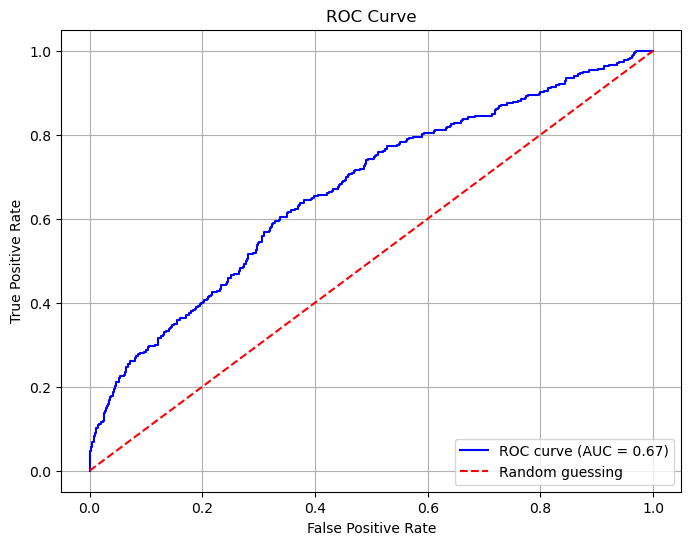

In [77]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# y_test → true labels
# y_pred_proba → predicted probability for class 1 (BUY)
# fpr → False Positive Rate = FP / (FP + TN)
# tpr → True Positive Rate = TP / (TP + FN)
# thresholds → probability thresholds used    
fpr, tpr, thrsholds = roc_curve(y_test, y_pred_proba)

# Compute area under curve
roc_auc = auc(fpr, tpr)

print("Blue curve → model")
print("Red dashed line → random guessing (AUC = 0.5)")
print("The closer the blue curve is to top-left, the better the model")

# Plot the ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='red', linestyle='--', label='Random guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### XGB Model Evaluation

In [78]:
features_labeled_10d_df.head()

,company,symbol,volume,trades,prev_close,open,high,low,close,change,change_percentage,date,dup_index,close_1d,close_3d,close_5d,close_10d,close_20d,close_60d,high_20,low_20,std_vol_20,ret_1,ret_3,ret_5,ret_10,ret_20,ret_60,std_close_5,std_close_10,std_close_20,range_5,atr_14,TR,volume_ratio,volume_z,avg_vol_10,avg_vol_20,liquidity_score,ma_ratio_5,ma_ratio_10,ma_ratio_20,price_position,breakout_flag,momentum_score,volatility_score,turnover_ratio,trend_angle,range_position,liquidity_rank,future_close_10d,future_return_10d,target_buy_10d,prob
0,LANKA ASHOK LEYLAND PLC,ASHO.N0000,368,32,3791.5,3760.00,3879.75,3755.0,3801.00,9.50,0.25,2025-12-31,1,3791.50,3819.00,3979.75,3806.25,NaN,NaN,4107.75,3749.75,1393.473104,0.002506,-0.004713,-0.044915,-0.001379,NaN,NaN,70.873699,80.231955,94.453431,278.00,115.714286,124.75,0.338593,-0.515869,1441.9,1086.85,0.174670,0.995052,0.996134,0.983982,0.191579,0,-0.012498,78.397122,0.086957,-9.761278,0.143156,261.0,4005.50,0.053802,1,0.139826
1,LANKA ASHOK LEYLAND PLC,ASHO.N0000,1180,68,3801.0,3969.75,3969.75,3840.0,3950.00,149.00,3.92,2026-01-02,1,3801.00,3749.75,3938.25,3811.00,4107.75,NaN,4007.50,3749.75,1376.325859,0.039200,0.053404,0.002984,0.036473,-0.038403,NaN,75.802375,90.678247,78.099232,259.75,124.160714,168.75,1.037044,0.030625,1539.3,1137.85,0.031759,1.033423,1.031426,1.024647,0.505263,0,0.027790,80.724508,0.057627,-4.650188,0.776916,266.0,3942.25,-0.001962,0,0.086924
2,LANKA ASHOK LEYLAND PLC,ASHO.N0000,214,32,3950.0,3950.00,3950.00,3886.0,3925.50,-24.50,-0.62,2026-01-05,1,3950.00,3791.50,3819.00,3753.25,4007.50,NaN,3979.75,3749.75,1391.771664,-0.006203,0.035342,0.027887,0.045894,-0.020462,NaN,88.551609,90.912752,71.549048,259.75,117.303571,64.00,0.195443,-0.632970,1372.4,1094.95,0.123709,1.021321,1.020439,1.019375,0.525610,0,0.014444,85.859440,0.149533,-1.234774,0.764130,267.0,3898.00,-0.007005,0,0.104389
3,LANKA ASHOK LEYLAND PLC,ASHO.N0000,833,76,3984.5,3900.00,4200.00,3900.0,4144.25,159.75,4.01,2026-01-08,1,3925.50,3801.00,3749.75,3753.25,3897.75,NaN,4144.25,3749.75,1371.945421,0.055725,0.090305,0.105207,0.104176,0.063242,NaN,143.057287,124.170271,96.815997,485.00,131.607143,300.00,0.807836,-0.144430,1066.0,1031.15,0.116676,1.056546,1.066463,1.072747,1.113462,1,0.080260,128.142925,0.091236,3.696053,1.000000,273.0,3884.50,-0.062677,0,0.048792
4,LANKA ASHOK LEYLAND PLC,ASHO.N0000,375,40,4011.0,4100.00,4144.00,3951.0,3979.00,-32.00,-0.80,2026-01-12,1,4144.25,3950.00,3791.50,3760.75,3883.25,NaN,4144.25,3749.75,1379.009808,-0.039875,0.007342,0.049453,0.058034,0.024657,NaN,123.369668,118.777734,100.168345,445.00,138.642857,193.25,0.378769,-0.446008,996.0,990.05,0.168934,1.004811,1.018220,1.028697,0.548980,0,0.006505,117.351823,0.106667,5.666541,0.581115,272.0,3865.25,-0.028588,0,0.128578


In [79]:
# fetch random rows
features_labeled_10d_df['future_return_10d'].sample(5)

8719   -0.072165
3464    0.063830
4992    0.002126
7708   -0.070263
1369   -0.242710
Name: future_return_10d, dtype: float64

In [80]:
from sklearn.metrics import accuracy_score, classification_report

preds = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds), "\n")
print(classification_report(y_test, preds))

Accuracy: 0.8680338831921534 

              precision    recall  f1-score   support

           0       0.88      0.99      0.93      1940
           1       0.57      0.10      0.16       303

    accuracy                           0.87      2243
   macro avg       0.72      0.54      0.55      2243
weighted avg       0.83      0.87      0.83      2243



## **Top-K Backtest**

In [ ]:
# features_labeled_10d_df['future_return_10d'] = features_labeled_10d_df['future_return_10d'].clip(-1, 1)
# features_labeled_10d_df = features_labeled_10d_df[features_labeled_10d_df['future_return_10d'].between(-1, 1)]

#### Calculate daily return
- For each day, calculate the average future 10-day return of the top 10 stocks
- This gives a daily portfolio return, assuming equal weighting of the top 10 stocks

In [ ]:
import duckdb

# Invesement money
invesement= 1

# Connect to an in-memory DuckDB database
con = duckdb.connect(database="cse_data.db")

# Load your pandas dataframe into DuckDB
# I want to treat this features_labeled_10d_df pandas DataFrame as a DuckDB table named stocks_10d_prob_table

con.register('stocks_10d_prob_table', features_labeled_10d_df)

# Pull Results Back into Python & Equity Curve
# For each date, it ranks the stocks by probability (prob) in descending order
# ROW_NUMBER() assigns 1 to the highest-probability stock, 2 to the next, and so on
# WHERE rn <= 10 AND future_return_10d IS NOT NULL
#       Filters only the top 10 stocks per day (rn <= 10)
#       Ignores rows where the future_return_10d is missing.
#       
daily_returns_df = con.execute("""
WITH ranked AS (
    SELECT
        *,
        ROW_NUMBER() OVER (PARTITION BY date ORDER BY prob DESC) AS rn
    FROM stocks_10d_prob_table
),
topk AS (
    SELECT *
    FROM ranked
    WHERE rn <= 10 AND future_return_10d IS NOT NULL
)
SELECT
    date,
    AVG(future_return_10d) AS daily_return
FROM topk
GROUP BY date
ORDER BY date
""").df()

# Compute equity curve in Python
# The total value of your ownership (your money invested + profit/loss)
daily_returns_df['equity'] = (invesement + daily_returns_df['daily_return']).cumprod()

daily_returns_df.tail()

### Performance Metrics for top 10 stocks all day
- All the metrics calculated — **Total Return**, **Sharpe Ratio**, **Win Rate**, **Max Drawdown**, etc. — are based only on the top 10 stocks per day that our strategy selected
- This is helpfull to us to get idea about how our model predicted top 10 stock were formanced we can trust thr model
- Not reccomended, but if we insvested in all these 10 stock every day we have thi return

In [ ]:
# equity = your portfolio growth over time
# Takes the last value of equity, Subtracts 1 (initial capital)
total_return = (daily_returns_df['equity'].iloc[-1] - invesement ) * 100

# Mean = average of all daily profit/loss
# how much you make per day
avg_return = daily_returns_df['daily_return'].mean()

# Standard deviation of daily returns
# How much your returns move up and down
# High volatility = risky (big swings)   &   Low volatility = stable
# How far returns are spread from average >>> 1% ok more than 5% not good
volatility = daily_returns_df['daily_return'].std()

# Why 252?   Because stock market has about 252 trading days per year.
# We multiply by √252 to convert daily Sharpe → yearly Sharpe
# What Sharpe means : Return per unit of risk
# How much return you are getting for the risk you are taking
# Higher = better
# < 1 → weak , 1–2 → good , 2–3 → strong , 3+ → very strong , 5+ → suspiciously strong
sharpe = avg_return / volatility * (252 ** 0.5)

# Check if each day return > 0 >>> This becomes True (1) or False (0) >>> Take mean
# How often you win
win_rate = (daily_returns_df['daily_return'] > 0).mean() * 100

# Biggest loss from peak to bottom
# cummax() >>> Gets highest equity reached so far
# equity / cummax() >>> How far below peak you are
# - 1 >>> Convert to percentage drop
# .min() >>> Get worst drop
max_drawdown = ((daily_returns_df['equity'] / daily_returns_df['equity'].cummax()) - 1).min()

print(f"Total Return : {total_return:.2f}%")
print(f"Avg Return : {avg_return:.2f}%")
print(f"Volatility : {volatility:.2f}")
print(f"Sharpe Ratio : {sharpe:.3f}")
print(f"Win Rate : {win_rate:.3f}%")
print(f"Max Drawdown : {max_drawdown:.3f}")

## Profit / Loss from a prticular day

In [ ]:
import numpy as np
import pandas as pd

def evaluate_strategy(start_date):

    # Filter from start date if provided

    df = daily_returns_df.copy()

    df['date'] = pd.to_datetime(df['date'])

    if start_date is not None:
        start_date = pd.to_datetime(start_date)
        df = df[df['date'] >= start_date].copy()
        
    # Check if filtered data is empty
    if df.empty:
        print(f"No data available from {start_date.date()}")
        return None
        
    total_return = (df['equity'].iloc[-1] - invesement ) * 100
    avg_return = df['daily_return'].mean()

    sharpe = 0
    if volatility != 0:
        sharpe = avg_return / volatility * np.sqrt(252)
        
    win_rate = (df['daily_return'] > 0).mean() * 100
    max_drawdown = ((df['equity'] / df['equity'].cummax()) - 1).min()

    results = {
        "Total Return from ": total_return,
        "Sharpe Ratio": sharpe,
        "Win Rate": win_rate,
        "Max Drawdown": max_drawdown
    }

    return results

# Shwoing
start_date="2025-11-18"
metrics = evaluate_strategy(start_date = start_date)

print("From : ", start_date, " to today\n")

if metrics is not None:
    for k, v in metrics.items():
        if "Return" in k or "Drawdown" in k or "Rate" in k:
            print(f"{k}: {v:.2%}")
        else:
            print(f"{k}: {v:.2f}")
else:
    print("No metrics to show because there is no data for this start date.")

In [ ]:
print(features_labeled_10d_df['future_return_10d'].describe())

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(daily_returns_df['date'], daily_returns_df['equity'], marker='o')
plt.title("Top 10 Stocks Equity Curve")
plt.xlabel("Date")
plt.ylabel("Equity ($1 invested)")
plt.grid(True)
plt.show()

## Top 10 stocks
- List the top 10 stock for each day by "prob" value

In [ ]:
# PARTITION BY date >>> This means “start a new ranking for each date.”
# ORDER BY prob DESC >>> Within that date, sort all stocks by model probability (prob) from highest to lowest
# ROW_NUMBER() >>> Assigns a sequential number starting from 1
# The highest probability stock of that day gets rank=1, second highest gets rank=2, …
# WHERE rank <= 10 >>> only want the Top 10 highest probability stocks for each date
topk_companies_df = con.execute("""
WITH ranked AS (
    SELECT
        date,
        company,
        symbol,
        prob,
        future_return_10d,
        target_buy_10,
        ROW_NUMBER() OVER (PARTITION BY date ORDER BY prob DESC) AS rank
    FROM stocks_10d_prob_table
)
SELECT *
FROM ranked
WHERE rank <= 10
ORDER BY date, rank
""").df()

topk_companies_df.tail(20)

# Note for columns

- **future_close_10d** : actual closing price 10 days after the current date

# 1️⃣ Core Algorithm: Gradient Boosted Trees (XGBoost / LightGBM) DONE

Perfect — now we’re talking **“money-first, best-possible model”** mode. Forget simplicity; we want **maximum predictive edge for CSE stocks**. Here’s how to do it properly:

---

# 🏆 Best-Performing Model Setup for Your Table

### **1️⃣ Core Algorithm: Gradient Boosted Trees (XGBoost / LightGBM)**

* Tree-based, handles tabular features perfectly
* Captures **non-linear relationships** and interactions in momentum, liquidity, volatility
* Produces **probabilities** → essential for Top-K trade picks

**Why not Random Forest or Neural Nets?**

* RF → good, but ceiling lower
* Neural Nets → overkill, unstable on small tabular data, need tons of training → overfit easily
* SVMs → slow, scale poorly for millions of rows

---

### **2️⃣ Ensemble for Extra Edge**

* XGBoost (main)
* Random Forest (sanity check / reduce false positives)
* Logistic Regression (baseline filter for extreme outliers)

> Voting or weighted average gives **robust predictions**, reduces risk of bad trades.

---

### **3️⃣ Feature Set (Max Signal)**

* Momentum: ret_5, ret_10, trend slope, range_position
* Volatility: std_close_10, ATR, drawdown_20
* Liquidity: volume_ratio, volume_z, liquidity_rank
* Relative Strength: rel_ret_5d_vs_ASPI, sector_rel_ret_5d
* Event Signals: pre_dividend_flag, days_to_dividend, rights_issue_flag

**Tip:** The more **high-signal, engineered features**, the better the trees perform.

---

### **4️⃣ Model Tuning**

* Use **walk-forward validation** → avoids overfit to historical data
* Optimize hyperparameters:

  ```
  n_estimators: 300–500
  learning_rate: 0.05–0.1
  max_depth: 3–7
  subsample: 0.7–0.9
  colsample_bytree: 0.7–0.9
  min_child_weight: 1–5
  ```
* Adjust probability threshold for **Top-K picks** → don’t just take 0.5 cutoff

---

### **5️⃣ Execution Workflow**

1. Run model weekly → predict probabilities for each stock
2. Filter by liquidity / volume / price thresholds
3. Select **Top 5–10 stocks** for actual trades
4. Apply stop-loss / take-profit rules → protect capital
5. Track performance → retrain model monthly

---

### **6️⃣ Optional Advanced Tricks**

* SHAP values → understand feature contribution → remove weak/noisy features
* Ensemble voting → reduce false positives
* Include **macro & market features**: ASPI returns, turnover, volatility index

---

💡 **Bottom line:**

* The **best possible setup** for your money-focused CSE trading is:
  **XGBoost (main) + optional Random Forest sanity check + engineered features + Top-K weekly picks + walk-forward validation + probability threshold tuning**

This is **state-of-the-art for tabular, structured stock data**, and gives the **highest chance of profitable trades**.

---

If you want, I can now make a **full blueprint for your dataset**, showing:

* Exact **features + transformations**
* Model setup & hyperparameters
* Thresholds & Top-K weekly trading logic

…ready to implement step by step for **maximum returns**.

Do you want me to do that?
